<a href="https://colab.research.google.com/github/Amirhossain959/geemap/blob/master/water_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade xee
!pip install -U geemap

In [ ]:
import ee
import geemap
import os
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
ee.Authenticate()
ee.Initialize(
    project= 'roads-and-highways',
    opt_url= 'https://earthengine-highvolume.googleapis.com'
)

In [ ]:
Map=geemap.Map()
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [ ]:
roi = ee.Geometry.Polygon(
        [[[144.24193354953593, -37.819597765792125],
          [144.24193354953593, -38.54714062824357],
          [145.58775874484843, -38.54714062824357],
          [145.58775874484843, -37.819597765792125]]], None, False)
Map.addLayer(roi, {}, 'Lake Victoria')
Map.centerObject(roi, 6)

# Harmonized Sentinel-2 MSI: MultiSpectral Instrument,Level-2A (SR)\
water quality, SR data (Level-2A for Sentinel) is highly recommended because it removes the "haze" that heavily affects the Blue band (B2)\
Dataset Availability: 2017-03-28T00:00:00Z–2026-02-17T07:13:59.117000Z\
Dataset Producer: European Union/ESA/Copernicus\
Revisit Interval: 5 Days\
Bands number: 26


# Water Indices
https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/se2waq/

chlorophyll-a (Chl-a)\
cyanobacteria density- cya\
turbidity-turb\
Colored Dissolved Organic Matter=CDOM\
Total Suspended solid = tss\
DO\
pH


In [ ]:
def water_indices(img):
  cloud_mask= img.select('probability').lt(20)
  ms= img.select('B.*').multiply(0.0001)
  ndwi= ms.normalizedDifference(['B3', 'B8']).rename('ndwi')
  water= ndwi.gt(0.1)
  tss= ms.expression(
      'b7*(b5/b2)', {
          'b2': ms.select('B2'),
          'b5': ms.select('B5'),
          'b7': ms.select('B7')
      }
  ).rename('tss')
  cdom= ms.expression(
     '537 * exp(-2.93 * (B03/B04))', {
         'B03': ms.select('B3'),
         'B04': ms.select('B4')
     }
  ).rename('cdom')
  chl= ms.expression(
      '4.26 * pow((B03/B01), 3.94)', {
          'B01': ms.select('B1'),
          'B03': ms.select('B3')
      }
  ).rename('chl')
  cya= ms.expression(
      '115530.31 * pow((B03 * B04) / B02, 2.38)',{
          'B02': ms.select('B2'),
          'B03': ms.select('B3'),
          'B04': ms.select('B4')
      }
  ).rename('cya')
  turb= ms.expression(
      '8.93 * (B03/B01) - 6.39',{
          'B01': ms.select('B1'),
          'B03': ms.select('B3')
      }
  ).rename('turb')
  doc= ms.expression(
      '432 * exp(-2.24* (B03/B04))', {
          'B03': ms.select('B3'),
          'B04': ms.select('B4')
      }
  ).rename('doc')
  col= ms.expression(
      '25366 * exp(-4.53*(B03/B04))', {
          'B03': ms.select('B3'),
          'B04': ms.select('B4')
      }
  ).rename('col')
  secchi= ms.expression(
      '26.447 + (-1672.777 * B2) + (266.620 * B3) + (1402.560 * B4) + (-58.610 * B5)',{
          'B2': ms.select('B2'),
          'B3': ms.select('B3'),
          'B4': ms.select('B4'),
          'B5': ms.select('B5')
      }
  ).rename('secchi')
  ph= ms.expression(
      '12.2621 + (-246.4698 * B1) + (29.4987 * B3) + (300.0727 * B6) + (-140.2648 * B8)', {
          'B1': ms.select('B1'),
          'B3': ms.select('B3'),
          'B6': ms.select('B6'),
          'B8': ms.select('B8')
      }
  ).rename('ph')
  do= ms.expression(
      '9.2505 + (-171.0251 * B2) + (236.9708 * B4) + (76.8288 * B6) + (-150.7815 * B11)', {
          'B2': ms.select('B2'),
          'B4': ms.select('B4'),
          'B6': ms.select('B6'),
          'B11': ms.select('B11')
      }
  ).rename('do')
  return (tss
  .addBands(cdom).addBands(chl).addBands(cya)
  .addBands(turb).addBands(doc).addBands(col).addBands(secchi).addBands(ph).addBands(do)
  .updateMask(cloud_mask)
  .updateMask(water).copyProperties(img, ['system:time_start']))

In [ ]:
sen2= ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
cloud_prob= ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY")
sen2= (
    sen2.linkCollection(cloud_prob, 'probability')
    # .filterDate('2022', '2025')
    .filterBounds(roi)
    .map(lambda x: water_indices(x))
    )


sen2.first().bandNames()

In [ ]:
wq_bands= sen2.first().bandNames().getInfo()
wq_bands

['tss', 'cdom', 'chl', 'cya', 'turb', 'doc', 'col', 'secchi', 'ph', 'do']

In [ ]:
time_start= ee.Date('2018')
time_end= ee.Date('2023')
time_diff= time_end.difference(time_start, 'month').round()
time_list= ee.List.sequence(0, time_diff).map(lambda t: time_start.advance(t, 'month'))
time_list

In [ ]:
# era5=(
#     ee.ImageCollection("ECMWF/ERA5/MONTHLY")
#     .filterDate(time_start, time_end)
#     .select(['mean_2m_air_temperature','total_precipitation'], ['temp', 'pr'])
# )
# era5.first().bandNames()

In [ ]:
climate_bands = ['aet', 'def', 'pdsi', 'pet', 'pr', 'ro', 'soil', 'srad', 'swe', 'tmmn', 'tmmx', 'vap', 'vpd', 'vs']
climate= (
    ee.ImageCollection("IDAHO_EPSCOR/TERRACLIMATE")
    .filterDate(time_start, time_end)
    .select(climate_bands)
)

In [ ]:
all_bands= sen2.first().bandNames().getInfo()+ climate.first().bandNames().getInfo()
all_bands

['tss',
 'cdom',
 'chl',
 'cya',
 'turb',
 'doc',
 'col',
 'secchi',
 'ph',
 'do',
 'aet',
 'def',
 'pdsi',
 'pet',
 'pr',
 'ro',
 'soil',
 'srad',
 'swe',
 'tmmn',
 'tmmx',
 'vap',
 'vpd',
 'vs']

In [ ]:
all_bands= ['tss','cdom','chl','cya','turb','doc','col','secchi', 'ph','do', 'aet', 'def', 'pdsi', 'pet', 'pr', 'ro', 'soil', 'srad', 'swe', 'tmmn', 'tmmx', 'vap', 'vpd', 'vs']

def create_homogenized_monthly_image(date):
  start_date = ee.Date(date)
  end_date = start_date.advance(1, 'month')

  # Create a template image with all expected bands filled with masked zeros, and explicitly cast to float32
  template_bands_list = []
  for b in all_bands:
    template_bands_list.append(ee.Image.constant(0).updateMask(ee.Image.constant(0)).rename(b).toFloat())
  template_image = ee.Image.cat(template_bands_list)

  # Retrieve raw monthly images, already pre-selected globally
  # And cast them to float32 upon retrieval
  wq_monthly = sen2.filterDate(start_date, end_date).median().toFloat()
  climate_monthly = climate.filterDate(start_date, end_date).median().toFloat()

  wq_bands= ['tss', 'cdom', 'chl', 'cya', 'turb', 'doc', 'col', 'secchi', 'ph', 'do']
  climate_bands= ['aet', 'def', 'pdsi', 'pet', 'pr', 'ro', 'soil', 'srad', 'swe', 'tmmn', 'tmmx', 'vap', 'vpd', 'vs']

    # Use ee.Algorithms.If to handle potential empty collections for dynamic data
  wq_data = ee.Image(ee.Algorithms.If(
      wq_monthly.bandNames().size().gt(0),
      wq_monthly.select(wq_bands),
      template_image.select(wq_bands)
    ))
  climate_data= ee.Image(ee.Algorithms.If(
      climate_monthly.bandNames().size().gt(0),
      climate_monthly.select(climate_bands),
      template_image.select(climate_bands)
    ))
    # Combine all data into the template image, overwriting masked zeros with actual data
  combined_image= (
      template_image
      .addBands(wq_data, None, True)
      .addBands(climate_data, None, True)
    )
  final_image= combined_image.select(all_bands).toFloat()
  return final_image.set('system:time_start', start_date.millis())

In [ ]:
collection= ee.ImageCollection(time_list.map(create_homogenized_monthly_image))
collection.first().bandNames()

In [ ]:
built= (
    ee.ImageCollection("JRC/GHSL/P2023A/GHS_BUILT_C")
    .select(['built_characteristics'], ['built'])
    .filterBounds(roi)
    .mode()
)
dem= (
    ee.Image("NASA/NASADEM_HGT/001")
    .select('elevation')
)

In [ ]:
collection= collection.map(
    lambda x: x.addBands(built).addBands(dem)
)

In [ ]:
ds= xr.open_dataset(
    collection,
    engine= 'ee',
    crs= 'epsg:4326',
    geometry= roi,
    scale= 0.01
)


In [ ]:
ds= ds.sortby('time') * 1
ds

<xarray.Dataset> Size: 63MB
Dimensions:    (time: 61, lon: 135, lat: 73)
Coordinates:
  * time       (time) datetime64[ns] 488B 2018-01-01 2018-02-01 ... 2023-01-01
  * lon        (lon) float64 1kB 144.2 144.3 144.3 144.3 ... 145.6 145.6 145.6
  * lat        (lat) float64 584B -38.54 -38.53 -38.52 ... -37.84 -37.83 -37.82
Data variables: (12/26)
    tss        (time, lon, lat) float32 2MB nan nan nan nan ... nan nan nan nan
    cdom       (time, lon, lat) float32 2MB nan nan nan nan ... nan nan nan nan
    chl        (time, lon, lat) float32 2MB nan nan nan nan ... nan nan nan nan
    cya        (time, lon, lat) float32 2MB nan nan nan nan ... nan nan nan nan
    turb       (time, lon, lat) float32 2MB nan nan nan nan ... nan nan nan nan
    doc        (time, lon, lat) float32 2MB nan nan nan nan ... nan nan nan nan
    ...         ...
    tmmx       (time, lon, lat) float32 2MB nan nan nan nan ... nan nan nan nan
    vap        (time, lon, lat) float32 2MB nan nan nan nan ... nan nan nan nan
    vpd        (time, lon, lat) float32 2MB nan nan nan nan ... nan nan nan nan
    vs         (time, lon, lat) float32 2MB nan nan nan nan ... nan nan nan nan
    built      (time, lon, lat) float32 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    elevation  (time, lon, lat) float32 2MB 0.0 0.0 0.0 ... 286.0 219.0 190.0
Attributes:
    crs:      epsg:4326

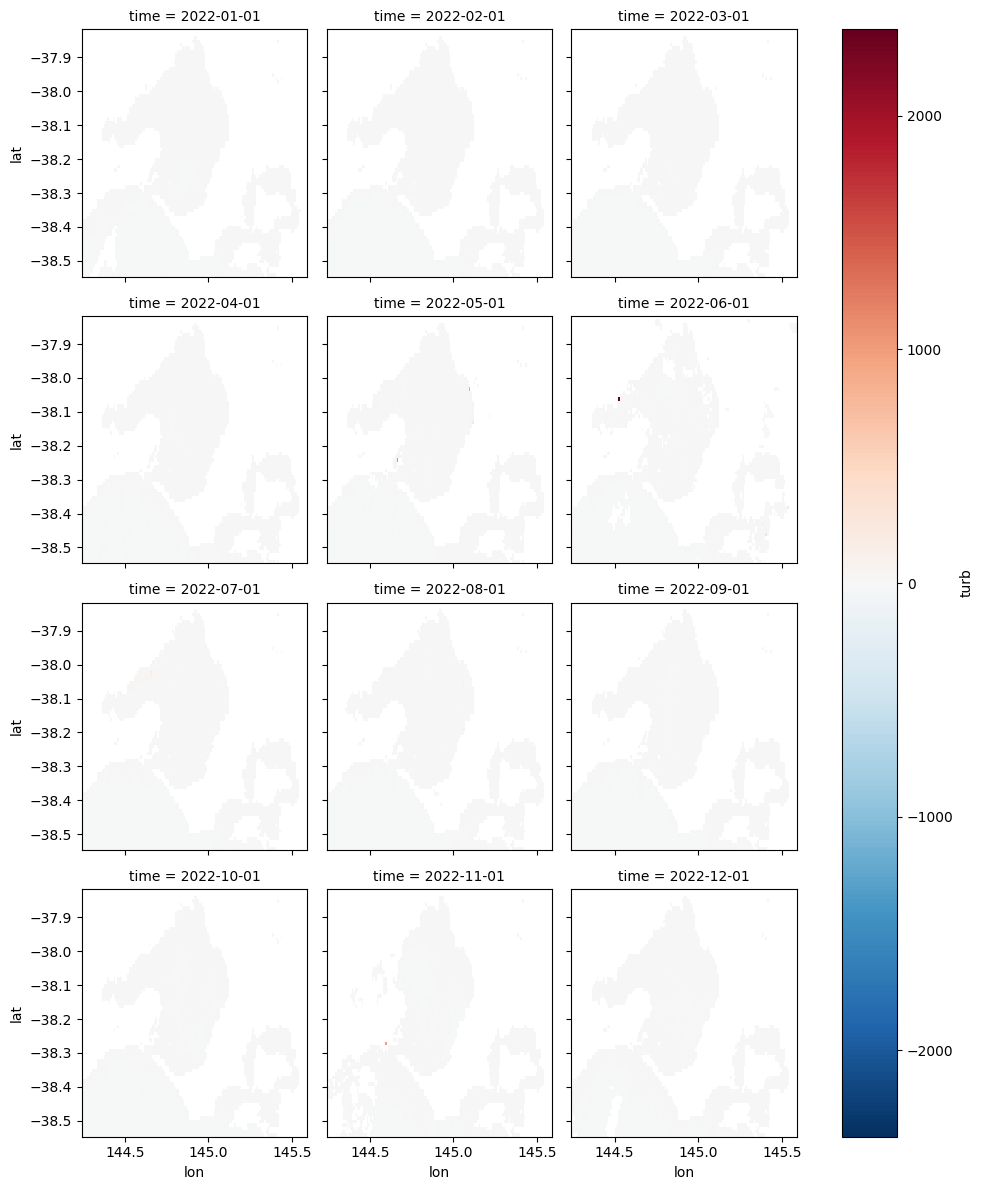

In [ ]:
ds2022= ds.sel(time= slice('2022-01-01', '2022-12-31'))
ds2022.turb.plot(
    x='lon', y= 'lat', col='time', col_wrap=3,
)

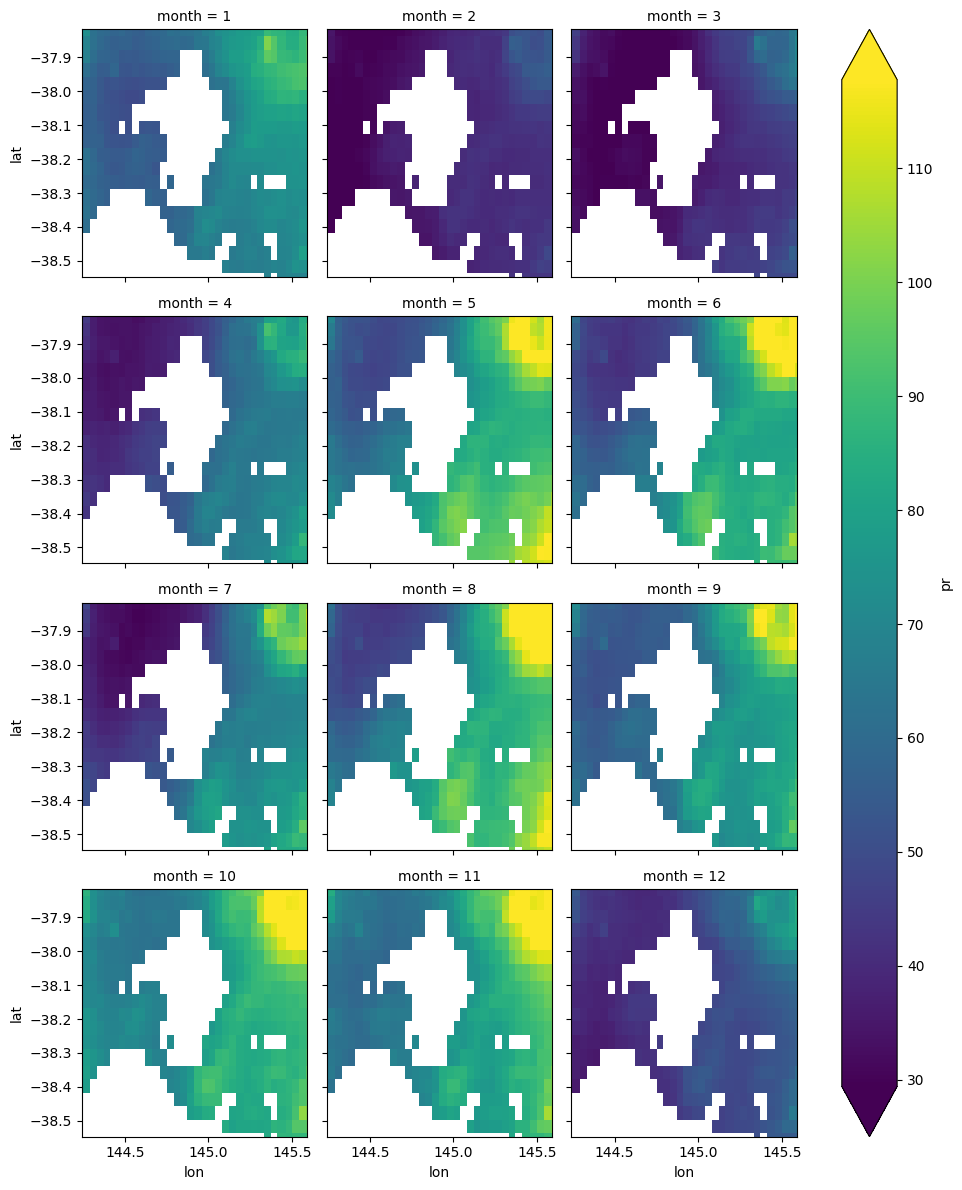

In [ ]:
ds_month= ds.resample(time='M').mean('time')
ds_month_group= ds_month.groupby('time.month').mean('time').pr.plot(
    x='lon', y= 'lat', col='month', col_wrap=3,robust=True
)

In [ ]:
ds_yearly= ds.resample(time='YE').mean('time')
ds_yearly

<xarray.Dataset> Size: 6MB
Dimensions:    (time: 6, lon: 135, lat: 73)
Coordinates:
  * time       (time) datetime64[ns] 48B 2018-12-31 2019-12-31 ... 2023-12-31
  * lon        (lon) float64 1kB 144.2 144.3 144.3 144.3 ... 145.6 145.6 145.6
  * lat        (lat) float64 584B -38.54 -38.53 -38.52 ... -37.84 -37.83 -37.82
Data variables: (12/26)
    tss        (time, lon, lat) float32 237kB 0.008002 0.008326 ... nan nan
    cdom       (time, lon, lat) float32 237kB 5.682 5.749 5.944 ... nan nan nan
    chl        (time, lon, lat) float32 237kB 0.3188 0.3304 0.4172 ... nan nan
    cya        (time, lon, lat) float32 237kB 8.487 9.35 11.05 ... nan nan nan
    turb       (time, lon, lat) float32 237kB -2.733 -2.631 -2.401 ... nan nan
    doc        (time, lon, lat) float32 237kB 10.76 10.86 11.12 ... nan nan nan
    ...         ...
    tmmx       (time, lon, lat) float32 237kB nan nan nan nan ... nan nan nan
    vap        (time, lon, lat) float32 237kB nan nan nan nan ... nan nan nan
    vpd        (time, lon, lat) float32 237kB nan nan nan nan ... nan nan nan
    vs         (time, lon, lat) float32 237kB nan nan nan nan ... nan nan nan
    built      (time, lon, lat) float32 237kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    elevation  (time, lon, lat) float32 237kB 0.0 0.0 0.0 ... 286.0 219.0 190.0
Attributes:
    crs:      epsg:4326

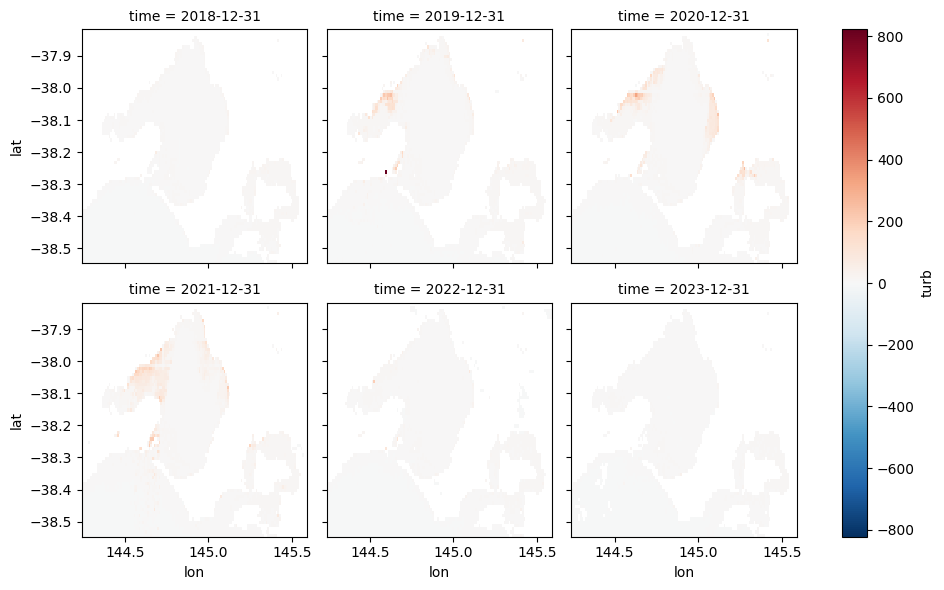

In [ ]:
ds_yearly.turb.plot(
    x='lon', y= 'lat', col='time', col_wrap=3,
)

In [ ]:
df= ds.to_dataframe()
df

tss  cdom  chl  cya  turb  doc  col  secchi  \
time       lon        lat                                                       
2018-01-01 144.246934 -38.542141  NaN   NaN  NaN  NaN   NaN  NaN  NaN     NaN   
                      -38.532141  NaN   NaN  NaN  NaN   NaN  NaN  NaN     NaN   
                      -38.522141  NaN   NaN  NaN  NaN   NaN  NaN  NaN     NaN   
                      -38.512141  NaN   NaN  NaN  NaN   NaN  NaN  NaN     NaN   
                      -38.502141  NaN   NaN  NaN  NaN   NaN  NaN  NaN     NaN   
...                               ...   ...  ...  ...   ...  ...  ...     ...   
2023-01-01 145.586934 -37.862141  NaN   NaN  NaN  NaN   NaN  NaN  NaN     NaN   
                      -37.852141  NaN   NaN  NaN  NaN   NaN  NaN  NaN     NaN   
                      -37.842141  NaN   NaN  NaN  NaN   NaN  NaN  NaN     NaN   
                      -37.832141  NaN   NaN  NaN  NaN   NaN  NaN  NaN     NaN   
                      -37.822141  NaN   NaN  NaN  NaN   NaN  NaN  NaN     NaN   

                                  ph  do  ...  soil  srad  swe  tmmn  tmmx  \
time       lon        lat                 ...                                
2018-01-01 144.246934 -38.542141 NaN NaN  ...   NaN   NaN  NaN   NaN   NaN   
                      -38.532141 NaN NaN  ...   NaN   NaN  NaN   NaN   NaN   
                      -38.522141 NaN NaN  ...   NaN   NaN  NaN   NaN   NaN   
                      -38.512141 NaN NaN  ...   NaN   NaN  NaN   NaN   NaN   
                      -38.502141 NaN NaN  ...   NaN   NaN  NaN   NaN   NaN   
...                               ..  ..  ...   ...   ...  ...   ...   ...   
2023-01-01 145.586934 -37.862141 NaN NaN  ...   NaN   NaN  NaN   NaN   NaN   
                      -37.852141 NaN NaN  ...   NaN   NaN  NaN   NaN   NaN   
                      -37.842141 NaN NaN  ...   NaN   NaN  NaN   NaN   NaN   
                      -37.832141 NaN NaN  ...   NaN   NaN  NaN   NaN   NaN   
                      -37.822141 NaN NaN  ...   NaN   NaN  NaN   NaN   NaN   

                                  vap  vpd  vs  built  elevation  
time       lon        lat                                         
2018-01-01 144.246934 -38.542141  NaN  NaN NaN    0.0        0.0  
                      -38.532141  NaN  NaN NaN    0.0        0.0  
                      -38.522141  NaN  NaN NaN    0.0        0.0  
                      -38.512141  NaN  NaN NaN    0.0        0.0  
                      -38.502141  NaN  NaN NaN    0.0        0.0  
...                               ...  ...  ..    ...        ...  
2023-01-01 145.586934 -37.862141  NaN  NaN NaN    0.0      239.0  
                      -37.852141  NaN  NaN NaN    0.0      290.0  
                      -37.842141  NaN  NaN NaN    0.0      286.0  
                      -37.832141  NaN  NaN NaN    0.0      219.0  
                      -37.822141  NaN  NaN NaN    0.0      190.0  

[601155 rows x 26 columns]

In [ ]:
df.isna().sum()

,0
tss,383785
cdom,383785
chl,383871
cya,383785
turb,383871
doc,383785
col,383785
secchi,383785
ph,383871
do,383785


In [ ]:
def filling_missing_values(data):
  data= data.fillna(method= 'ffill')
  data= data.fillna(method= 'bfill')
  return data

df= filling_missing_values(df)
df.isna().sum()

,0
tss,0
cdom,0
chl,0
cya,0
turb,0
doc,0
col,0
secchi,0
ph,0
do,0


In [ ]:
df.describe()


,tss,cdom,chl,cya,turb,doc,col,secchi,ph,do,...,soil,srad,swe,tmmn,tmmx,vap,vpd,vs,built,elevation
count,601155.000000,601155.000000,6.011550e+05,601155.000000,601155.000000,601155.000000,601155.000000,601155.000000,601155.000000,601155.000000,...,601155.000000,601155.000000,601155.0,601155.000000,601155.000000,601155.000000,601155.000000,601155.000000,601155.000000,601155.000000
mean,0.016522,7.032116,1.105619e+07,159.158844,12.594921,12.514019,93.473839,7.935581,8.238704,8.426940,...,549.463745,1769.527588,0.0,100.537849,194.412827,1178.918823,58.740166,548.601562,0.932116,39.197052
std,0.038581,22.484684,4.562727e+08,3519.866943,72.627754,21.159800,1006.833313,21.065432,4.591731,3.772937,...,612.655640,754.094360,0.0,31.535484,43.252369,200.844513,25.668112,86.996010,3.403050,66.130554
min,0.000000,0.000000,0.000000e+00,0.000000,-6.390000,0.000000,0.000000,-229.679886,-98.480820,-0.327510,...,11.000000,651.000000,0.0,35.000000,108.000000,788.000000,12.000000,310.000000,0.000000,0.000000
25%,0.001314,0.155196,3.204759e+00,0.862221,1.860824,0.821540,0.093343,-4.067138,6.923422,6.188792,...,82.000000,1020.000000,0.0,72.000000,155.000000,1023.000000,37.000000,490.000000,0.000000,0.000000
50%,0.006705,2.495593,1.294365e+01,9.692738,5.303919,6.954934,6.598279,4.764864,8.510144,7.079390,...,274.000000,1744.000000,0.0,98.000000,195.000000,1138.000000,55.000000,550.000000,0.000000,9.000000
75%,0.020784,8.690678,4.462862e+01,71.445587,9.756406,18.324879,44.815145,15.936682,10.395226,9.077069,...,866.000000,2454.000000,0.0,127.000000,231.000000,1314.000000,78.000000,600.000000,0.000000,53.000000
max,1.469786,537.000000,4.782089e+10,163714.765625,2895.860107,432.000000,25366.000000,425.407166,39.818707,52.780354,...,2728.000000,3190.000000,0.0,189.000000,299.000000,1910.000000,138.000000,920.000000,24.000000,564.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 601155 entries, (Timestamp('2018-01-01 00:00:00'), np.float64(144.24693354953592), np.float64(-38.542140628243565)) to (Timestamp('2023-01-01 00:00:00'), np.float64(145.58693354953593), np.float64(-37.82214062824357))
Data columns (total 26 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   tss        601155 non-null  float32
 1   cdom       601155 non-null  float32
 2   chl        601155 non-null  float32
 3   cya        601155 non-null  float32
 4   turb       601155 non-null  float32
 5   doc        601155 non-null  float32
 6   col        601155 non-null  float32
 7   secchi     601155 non-null  float32
 8   ph         601155 non-null  float32
 9   do         601155 non-null  float32
 10  aet        601155 non-null  float32
 11  def        601155 non-null  float32
 12  pdsi       601155 non-null  float32
 13  pet        601155 non-null  float32
 14  pr         601155 non-null  float32
 1

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error
from sklearn.linear_model import LogisticRegression, Perceptron, SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import time

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import time

import tensorflow as tf
from tensorflow.keras.layers import Dense, Activation
# Dense Neural Network
from tensorflow.keras.layers import Dense, Dropout
# Sequential Connection with Neural Network
from tensorflow.keras.models import Sequential
# Optimizers for Regression Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, PReLU

#from tensorflow.keras.layers import PReLU, ELU, Activation
#from tensorflow.keras.layers import Dense, LeakyReLU
from keras.layers import Dense, Activation, LeakyReLU, PReLU, ELU

In [ ]:
df.swe.value_counts()

,count
swe,
0.0,601155


In [ ]:
df= df.drop( columns=['swe'], axis=1)
df.columns

Index(['tss', 'cdom', 'chl', 'cya', 'turb', 'doc', 'col', 'secchi', 'ph', 'do',
       'aet', 'def', 'pdsi', 'pet', 'pr', 'ro', 'soil', 'srad', 'tmmn', 'tmmx',
       'vap', 'vpd', 'vs', 'built', 'elevation'],
      dtype='object')

In [ ]:
df.corr(numeric_only=True)


,tss,cdom,chl,cya,turb,doc,col,secchi,ph,do,...,ro,soil,srad,tmmn,tmmx,vap,vpd,vs,built,elevation
tss,1.000000,0.166533,-0.004628,0.837589,-0.014118,0.306461,0.016628,0.555474,-0.078479,0.638660,...,0.018986,0.080232,0.158715,0.111310,0.147839,0.129058,0.117090,-0.025835,-0.004337,0.122920
cdom,0.166533,1.000000,-0.004987,0.034103,-0.018696,0.951335,0.957784,0.216655,0.041216,0.283594,...,0.030937,0.059815,0.029685,-0.015323,0.013105,-0.002930,-0.003589,-0.043047,-0.025632,0.058965
chl,-0.004628,-0.004987,1.000000,-0.000842,0.622969,-0.008186,-0.001957,0.016643,0.026857,0.004263,...,-0.003965,0.006191,-0.030250,-0.021167,-0.024421,-0.013071,-0.026012,-0.017351,0.013340,0.003300
cya,0.837589,0.034103,-0.000842,1.000000,-0.001950,0.057329,0.005831,0.432991,-0.027667,0.293846,...,-0.002943,0.011002,0.009734,0.024816,0.031195,0.039096,0.021871,-0.025686,-0.007242,0.030580
turb,-0.014118,-0.018696,0.622969,-0.001950,1.000000,-0.030820,-0.009603,0.082598,0.129129,0.030466,...,-0.010547,0.010620,-0.128733,-0.096766,-0.107372,-0.070096,-0.111682,-0.046525,0.032978,0.012411
doc,0.306461,0.951335,-0.008186,0.057329,-0.030820,1.000000,0.824872,0.367370,0.038429,0.499450,...,0.059026,0.126352,0.123430,0.028700,0.085506,0.044268,0.058706,-0.054247,-0.036256,0.115431
col,0.016628,0.957784,-0.001957,0.005831,-0.009603,0.824872,1.000000,0.044042,0.027775,0.042921,...,-0.001071,-0.008945,-0.044047,-0.044506,-0.042723,-0.035147,-0.046288,-0.022972,-0.011597,0.002321
secchi,0.555474,0.216655,0.016643,0.432991,0.082598,0.367370,0.044042,1.000000,0.526157,0.763171,...,0.083087,0.223974,0.024557,-0.046215,0.028145,-0.021597,-0.013831,-0.141721,-0.004802,0.175798
ph,-0.078479,0.041216,0.026857,-0.027667,0.129129,0.038429,0.027775,0.526157,1.000000,0.121422,...,0.026382,0.077129,-0.159949,-0.155539,-0.150750,-0.155181,-0.152343,-0.051188,0.027308,0.006285
do,0.638660,0.283594,0.004263,0.293846,0.030466,0.499450,0.042921,0.763171,0.121422,1.000000,...,0.109913,0.282910,0.072353,-0.020409,0.059986,0.007643,0.003374,-0.136791,-0.034926,0.228830


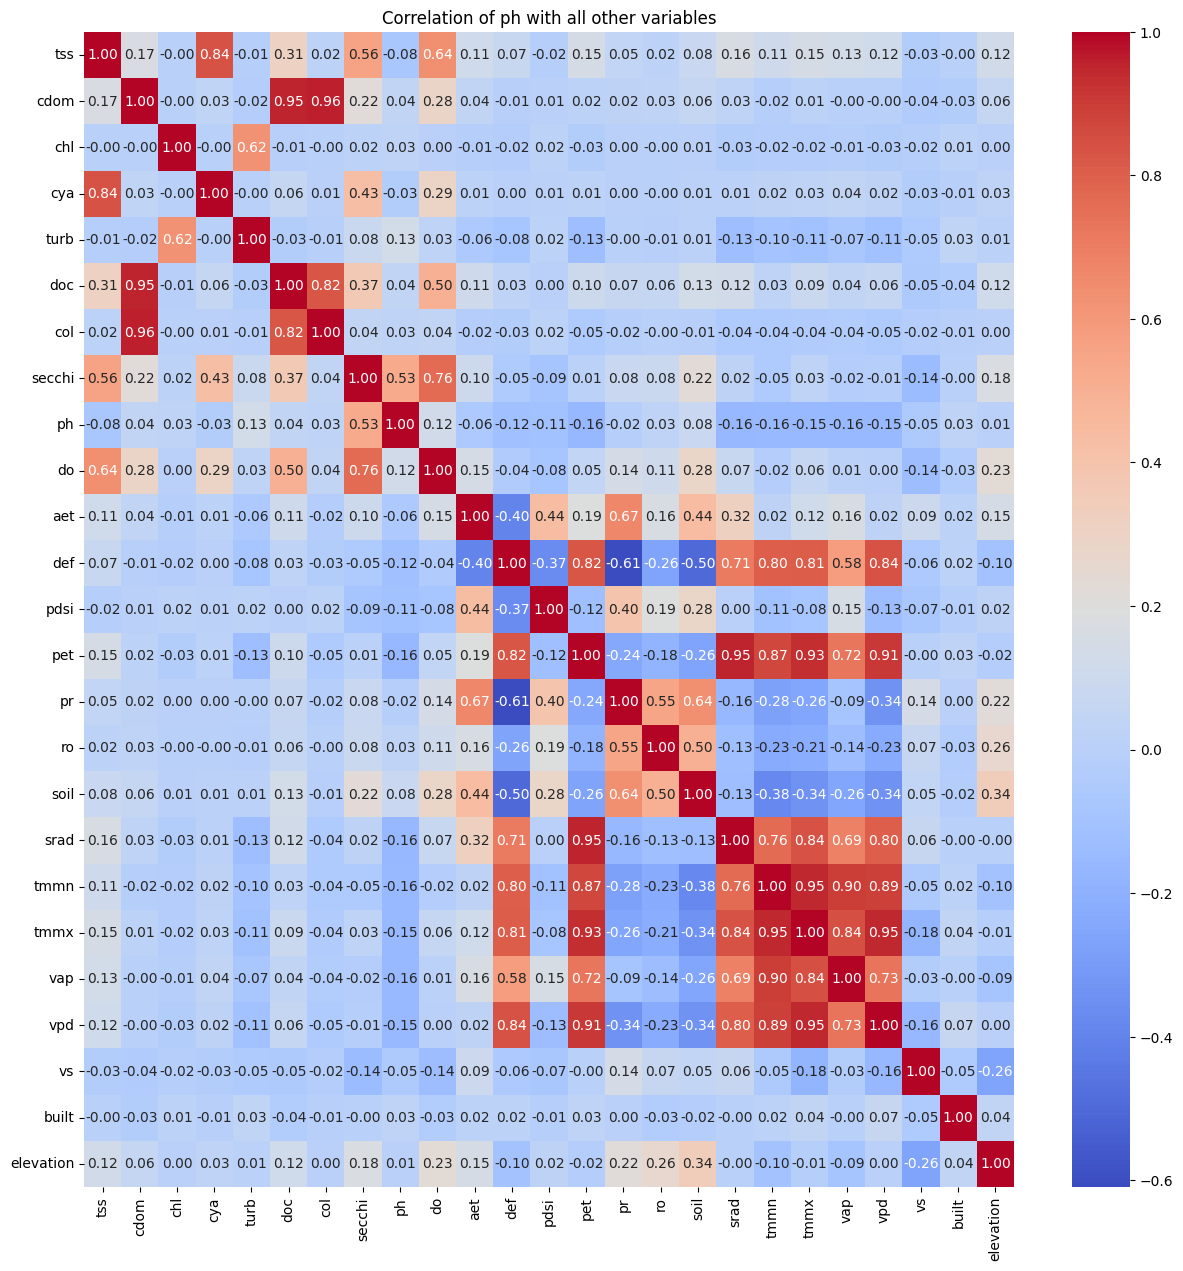

In [ ]:
plt.figure(figsize=(15,15)) # Adjust figsize for a single row
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation of ph with all other variables')
plt.show()

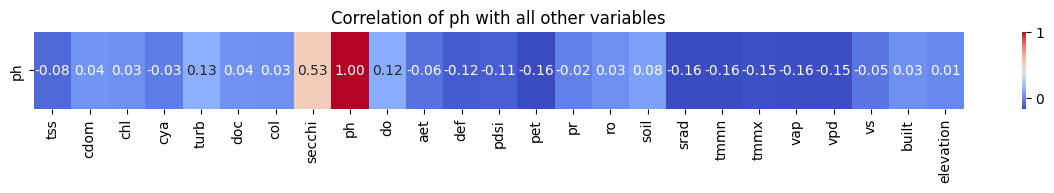

In [ ]:
plt.figure(figsize=(15,1)) # Adjust figsize for a single row
sns.heatmap(df.corr().loc[['ph']], annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation of ph with all other variables')
plt.show()

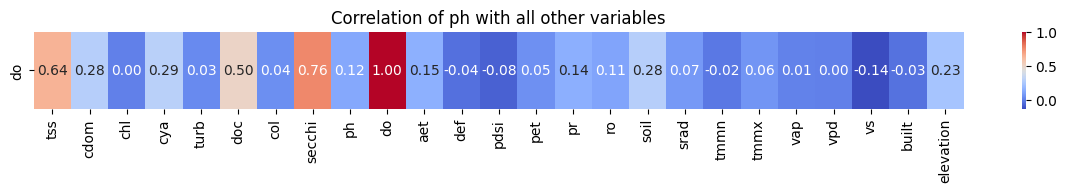

In [ ]:
plt.figure(figsize=(15,1)) # Adjust figsize for a single row
sns.heatmap(df.corr().loc[['do']], annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation of ph with all other variables')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error
from sklearn.linear_model import LogisticRegression, Perceptron, SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import time

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import time

import tensorflow as tf
from tensorflow.keras.layers import Dense, Activation
# Dense Neural Network
from tensorflow.keras.layers import Dense, Dropout
# Sequential Connection with Neural Network
from tensorflow.keras.models import Sequential
# Optimizers for Regression Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, PReLU

#from tensorflow.keras.layers import PReLU, ELU, Activation
#from tensorflow.keras.layers import Dense, LeakyReLU
from keras.layers import Dense, Activation, LeakyReLU, PReLU, ELU

In [ ]:
df.columns

Index(['tss', 'cdom', 'chl', 'cya', 'turb', 'doc', 'col', 'secchi', 'ph', 'do',
       'aet', 'def', 'pdsi', 'pet', 'pr', 'ro', 'soil', 'srad', 'tmmn', 'tmmx',
       'vap', 'vpd', 'vs', 'built', 'elevation'],
      dtype='object')

In [ ]:
X = df[['aet', 'def', 'pdsi', 'pet', 'pr', 'ro', 'soil', 'srad', 'tmmn', 'tmmx',
       'vap', 'vpd', 'vs']]
y = df['do']
X

aet     def   pdsi     pet     pr   ro  \
time       lon        lat                                                     
2018-01-01 144.246934 -38.542141   418.0  1450.0 -410.0  1868.0   43.0  2.0   
                      -38.532141   418.0  1450.0 -410.0  1868.0   43.0  2.0   
                      -38.522141   418.0  1450.0 -410.0  1868.0   43.0  2.0   
                      -38.512141   418.0  1450.0 -410.0  1868.0   43.0  2.0   
                      -38.502141   418.0  1450.0 -410.0  1868.0   43.0  2.0   
...                                  ...     ...    ...     ...    ...  ...   
2023-01-01 145.586934 -37.862141  1356.0   136.0  384.0  1492.0  118.0  6.0   
                      -37.852141  1356.0   136.0  384.0  1492.0  118.0  6.0   
                      -37.842141  1356.0   136.0  384.0  1492.0  118.0  6.0   
                      -37.832141  1356.0   136.0  384.0  1492.0  118.0  6.0   
                      -37.822141  1356.0   136.0  384.0  1492.0  118.0  6.0   

                                    soil    srad   tmmn   tmmx     vap   vpd  \
time       lon        lat                                                      
2018-01-01 144.246934 -38.542141    88.0  2979.0  144.0  253.0  1323.0  78.0   
                      -38.532141    88.0  2979.0  144.0  253.0  1323.0  78.0   
                      -38.522141    88.0  2979.0  144.0  253.0  1323.0  78.0   
                      -38.512141    88.0  2979.0  144.0  253.0  1323.0  78.0   
                      -38.502141    88.0  2979.0  144.0  253.0  1323.0  78.0   
...                                  ...     ...    ...    ...     ...   ...   
2023-01-01 145.586934 -37.862141  1953.0  2827.0  104.0  231.0  1221.0  83.0   
                      -37.852141  1953.0  2827.0  104.0  231.0  1221.0  83.0   
                      -37.842141  1953.0  2827.0  104.0  231.0  1221.0  83.0   
                      -37.832141  1953.0  2827.0  104.0  231.0  1221.0  83.0   
                      -37.822141  1953.0  2827.0  104.0  231.0  1221.0  83.0   

                                     vs  
time       lon        lat                
2018-01-01 144.246934 -38.542141  570.0  
                      -38.532141  570.0  
                      -38.522141  570.0  
                      -38.512141  570.0  
                      -38.502141  570.0  
...                                 ...  
2023-01-01 145.586934 -37.862141  400.0  
                      -37.852141  400.0  
                      -37.842141  400.0  
                      -37.832141  400.0  
                      -37.822141  400.0  

[601155 rows x 13 columns]

In [ ]:
# standard scaler
scaler= StandardScaler()
X= scaler.fit_transform(X)
y

time        lon         lat       
2018-01-01  144.246934  -38.542141     5.739176
                        -38.532141     5.739176
                        -38.522141     5.739176
                        -38.512141     5.739176
                        -38.502141     5.739176
                                        ...    
2023-01-01  145.586934  -37.862141    13.999652
                        -37.852141    13.999652
                        -37.842141    13.999652
                        -37.832141    13.999652
                        -37.822141    13.999652
Name: do, Length: 601155, dtype: float32

In [ ]:
# Assume 'target' is the column you want to predict
X = X
y = y

# Encode labels if they are not numerical
le = LabelEncoder()
y = le.fit_transform(y)

# Split the dataset into training, testing, and validation sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.3, random_state=42)

# Define models to be evaluated
models = {
    'Logistic Regression': LogisticRegression(),
    'Support Vector Machines': SVC(),
    'Linear SVC': LinearSVC(),
    'k-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Perceptron': Perceptron(),
    'Stochastic Gradient Descent': SGDClassifier(),
    'Decision Tree Classifier': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'XGBClassifier': XGBClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'AdaBoostClassifier': AdaBoostClassifier(),
}

In [ ]:
# Initialize an empty list to store the results
results_list = []

# Training and evaluating the models
for model_name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)

    # Training set
    y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, average='weighted')
    train_recall = recall_score(y_train, y_train_pred, average='weighted')
    train_f1 = f1_score(y_train, y_train_pred, average='weighted')

    # Testing set
    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='weighted')
    test_recall = recall_score(y_test, y_test_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')

    # Validation set
    y_val_pred = model.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, average='weighted')
    val_recall = recall_score(y_val, y_val_pred, average='weighted')
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    # Store results in the list
    results_list.append({
        'Model': model_name,
        'Training Accuracy': train_accuracy,
        'Testing Accuracy': test_accuracy,
        'Validation Accuracy': val_accuracy,
        'CPU times': time.time() - start_time,
        'MSE': val_mse,  # Use validation MSE as the overall MSE
        'Precision': train_precision,
        'Recall': train_recall,
        'F1 Score': train_f1
    })

# Convert the results list to a DataFrame
results_df = pd.DataFrame(results_list)

# Display the results
results_df

In [ ]:
# Split the dataset into training, testing, and validation sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
X_train.shape[1]

In [ ]:
def build_model():
    model = Sequential()
    model.add(Dense(units = 64, activation = 'relu', input_dim = X_train.shape[1]))
    model.add(Dense(units = 128, activation = 'relu'))
    model.add(Dense(units = 128, activation = 'relu'))
    # Output Layer - For multi-class classification
    model.add(Dense(units = num_classes, activation = 'softmax')) # Changed to num_classes and softmax

    optimizers = Adam(learning_rate = 0.001)

    # Model Compiler - Error Function for multi-class with integer labels = 'sparse_categorical_crossentropy'
    model.compile(loss = 'sparse_categorical_crossentropy', optimizer = optimizers, metrics = ['accuracy']) # Changed loss and metrics

    return model

In [ ]:
model1 = build_model()

In [ ]:
model1.summary()

In [ ]:
history1= model1.fit(X_train, y_train, epochs= 100, batch_size=32, validation_data=(X_val, y_val))


In [ ]:
pd.DataFrame(history1.history)[['accuracy', 'val_accuracy']].plot()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_probabilities = model1.predict(X_test)
y_pred_classes = np.argmax(y_pred_probabilities, axis=1) # Get predicted class for each sample

# Evaluate using classification metrics
test_accuracy = accuracy_score(y_test, y_pred_classes)
print(f'Test Accuracy: {test_accuracy:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_classes, zero_division=0))